<a href="https://colab.research.google.com/github/Kintsukuro1/Mineria-Datos/blob/main/Coffe_Shop_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descripción del Dataset

El dataset Coffee Shop Sales contiene información sobre ventas
realizadas en una cafetería.

Incluye variables como:

- transaction_id
- transaction_qty
- unit_price
- product_category
- product_detail

El objetivo es analizar patrones de compra y realizar predicciones
sobre ventas.

In [27]:
import warnings
warnings.filterwarnings('ignore')

!pip install mlxtend openpyxl

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [28]:
df = pd.read_excel('Coffee Shop Sales.xlsx')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [29]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')

In [30]:
basket = df.groupby(['transaction_id', 'product_detail'])['product_detail'] \
           .count().unstack().fillna(0)

In [31]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()

product_detail,Almond Croissant,Brazilian - Organic,Brazilian Lg,Brazilian Rg,Brazilian Sm,Cappuccino,Cappuccino Lg,Carmel syrup,Chili Mayan,Chocolate Chip Biscotti,...,Spicy Eye Opener Chai,Spicy Eye Opener Chai Lg,Spicy Eye Opener Chai Rg,Sugar Free Vanilla syrup,Sustainably Grown Organic,Sustainably Grown Organic Lg,Sustainably Grown Organic Rg,Traditional Blend Chai,Traditional Blend Chai Lg,Traditional Blend Chai Rg
transaction_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [32]:
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)

frequent_items.head()

,support,itemsets
0,0.020628,(Chocolate Croissant)
1,0.020206,(Columbian Medium Roast Rg)
2,0.020313,(Dark chocolate Lg)
3,0.020474,(Earl Grey Rg)
4,0.020052,(Latte)


In [33]:
rules = association_rules(frequent_items, metric='lift', min_threshold=1)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()

,antecedents,consequents,support,confidence,lift


Interpretación de Resultados
Conceptos
Support

Frecuencia con la que aparecen productos juntos.

Confidence

Probabilidad de que un cliente compre un producto si ya compró otro.

Lift

Mide qué tan fuerte es la relación entre productos.

Lift > 1 → relación positiva.
Lift = 1 → no hay relación.
Lift < 1 → relación negativa.

In [34]:
df['Total_Bill'] = (
    df['transaction_qty'] *
    df['unit_price']
)

X = df[['transaction_qty', 'unit_price']]
y = df['Total_Bill']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [36]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('R2:', r2)

MAE: 0.5115060526448805
MSE: 0.5843620845207137
R2: 0.9360842045103704


Interpretación
MAE

Error promedio absoluto.

Mientras más pequeño, mejor.

MSE

Error cuadrático medio.

Penaliza errores grandes.

R2 Score

Indica qué tan bien el modelo explica los datos.

Cerca de 1 → excelente.
Cerca de 0 → malo.

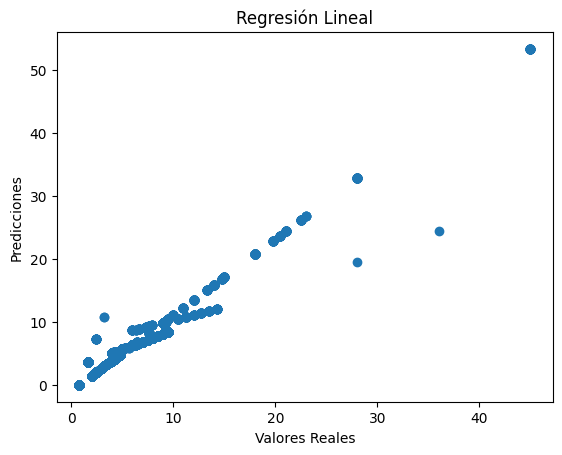

In [37]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Regresión Lineal')
plt.show()

# Regresión Lineal Múltiple

Se utilizó regresión lineal múltiple porque el modelo utiliza más de
una variable explicativa:

- transaction_qty
- unit_price

Estas variables permiten predecir el Total_Bill.

# Conclusiones

El Market Basket Analysis permitió identificar relaciones entre
productos comprados frecuentemente juntos.

La regresión lineal múltiple permitió predecir el total de ventas
utilizando cantidad y precio unitario.

Los resultados muestran que el modelo posee una buena capacidad
predictiva.